In [1]:
"""
Statistical analysis of Day 3 multi-problem benchmark.

Loads the 3 JSON result files from results/exp_02_*.json, runs Friedman + Nemenyi
post-hoc tests on the final regret values, and produces a critical difference diagram.
"""
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scikit_posthocs as sp
from scipy import stats

warnings.filterwarnings("ignore")

# Find the project root (parent of notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"

PROBLEMS = ["branin", "hartmann6", "ackley"]
STRATEGIES = ["EI", "UCB", "Random"]

# Load all 3 experiment results
data = {}
for problem in PROBLEMS:
    path = RESULTS_DIR / f"exp_02_{problem}_strategies.json"
    with open(path) as f:
        data[problem] = json.load(f)
    print(f"Loaded {path.name}")
    print(f"  config: {data[problem]['config']}")
    print(f"  strategies: {list(data[problem]['results'].keys())}")
    print()

print("All data loaded.")

Loaded exp_02_branin_strategies.json
  config: {'problem': 'Branin', 'seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'n_iter': 20}
  strategies: ['EI', 'UCB', 'Random']

Loaded exp_02_hartmann6_strategies.json
  config: {'problem': 'Hartmann6', 'seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'n_iter': 20}
  strategies: ['EI', 'UCB', 'Random']

Loaded exp_02_ackley_strategies.json
  config: {'problem': 'Ackley', 'seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'n_iter': 20}
  strategies: ['EI', 'UCB', 'Random']

All data loaded.


In [2]:
# Extract final regret per (problem, strategy, seed)
# Each cell in data[problem]["results"][strategy] is a (n_seeds, n_iter+1) trajectory
# We take the last column = final regret per seed

final_regrets = {}  # final_regrets[problem][strategy] = array of shape (n_seeds,)
for problem in PROBLEMS:
    final_regrets[problem] = {}
    for strategy in STRATEGIES:
        traj = np.array(data[problem]["results"][strategy])  # (10, 21)
        final_regrets[problem][strategy] = traj[:, -1]  # (10,)

# Sanity-check: print shape and mean/median for each (problem, strategy)
print(f"{'Problem':<12} {'Strategy':<10} {'Shape':<10} {'Mean':>10} {'Median':>10}")
print("-" * 56)
for problem in PROBLEMS:
    for strategy in STRATEGIES:
        arr = final_regrets[problem][strategy]
        print(f"{problem:<12} {strategy:<10} {str(arr.shape):<10} {arr.mean():>10.4f} {np.median(arr):>10.4f}")

Problem      Strategy   Shape            Mean     Median
--------------------------------------------------------
branin       EI         (10,)          0.0605     0.0469
branin       UCB        (10,)          0.1685     0.0077
branin       Random     (10,)          1.5829     0.9199
hartmann6    EI         (10,)          0.2219     0.1833
hartmann6    UCB        (10,)          0.4154     0.2541
hartmann6    Random     (10,)          1.8068     1.8019
ackley       EI         (10,)          7.4403     7.3599
ackley       UCB        (10,)          7.7857     7.6699
ackley       Random     (10,)          8.1257     8.2723


In [3]:
# Build the Friedman input matrix: rows = (problem, seed) blocks, columns = strategies
# Shape: (N_problems * N_seeds, N_strategies) = (3*10, 3) = (30, 3)

rows = []
block_labels = []  # for debugging: which (problem, seed) is each row
for problem in PROBLEMS:
    n_seeds = len(final_regrets[problem]["EI"])
    for seed_idx in range(n_seeds):
        row = [final_regrets[problem][strategy][seed_idx] for strategy in STRATEGIES]
        rows.append(row)
        block_labels.append(f"{problem}_seed{seed_idx}")

friedman_matrix = np.array(rows)  # (30, 3)
print(f"Friedman input matrix shape: {friedman_matrix.shape}")
print(f"Columns (strategies): {STRATEGIES}")
print(f"First 3 rows (should be branin seeds 0,1,2):")
print(pd.DataFrame(friedman_matrix[:3], columns=STRATEGIES, index=block_labels[:3]))
print()

# Run Friedman test
# scipy expects K separate arrays, one per "group" (strategy here)
chi2, p_value = stats.friedmanchisquare(
    *[friedman_matrix[:, i] for i in range(len(STRATEGIES))]
)

print(f"=== Friedman test ===")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  p-value: {p_value:.6e}")
print(f"  Degrees of freedom: {len(STRATEGIES) - 1}")
print()

if p_value < 0.05:
    print(f"  Result: REJECT H0 (p < 0.05)")
    print(f"          At least one strategy differs significantly from the others.")
else:
    print(f"  Result: Cannot reject H0 (p = {p_value:.4f})")
    print(f"          No statistically significant difference among strategies.")

Friedman input matrix shape: (30, 3)
Columns (strategies): ['EI', 'UCB', 'Random']
First 3 rows (should be branin seeds 0,1,2):
                    EI       UCB    Random
branin_seed0  0.000238  0.001642  2.833123
branin_seed1  0.106162  0.004806  3.469540
branin_seed2  0.094533  0.000496  1.064024

=== Friedman test ===
  Chi-square statistic: 28.5299
  p-value: 6.379810e-07
  Degrees of freedom: 2

  Result: REJECT H0 (p < 0.05)
          At least one strategy differs significantly from the others.


In [4]:
# Nemenyi post-hoc: pairwise comparisons after Friedman rejection
# scikit-posthocs returns a p-value matrix where cell (i, j) is the
# p-value for the null hypothesis "strategies i and j have equal ranks"

# Build a DataFrame in long format for scikit-posthocs
# Required columns: groups (strategy) and value (final regret), with block info via index
df_long = pd.DataFrame(friedman_matrix, columns=STRATEGIES, index=block_labels)
print("Wide-format input to Nemenyi:")
print(df_long.head())
print()

# Run Nemenyi
# posthoc_nemenyi_friedman expects a wide-format matrix (blocks x groups)
nemenyi_pvalues = sp.posthoc_nemenyi_friedman(friedman_matrix)
nemenyi_pvalues.columns = STRATEGIES
nemenyi_pvalues.index = STRATEGIES

print("=== Nemenyi post-hoc p-value matrix ===")
print(nemenyi_pvalues.round(6))
print()

# Interpret pairwise
print("=== Pairwise significance at alpha=0.05 ===")
for i, s1 in enumerate(STRATEGIES):
    for j, s2 in enumerate(STRATEGIES):
        if i < j:
            p = nemenyi_pvalues.iloc[i, j]
            verdict = "significantly different" if p < 0.05 else "NOT significantly different"
            print(f"  {s1} vs {s2}: p = {p:.6f} -> {verdict}")

Wide-format input to Nemenyi:
                    EI       UCB    Random
branin_seed0  0.000238  0.001642  2.833123
branin_seed1  0.106162  0.004806  3.469540
branin_seed2  0.094533  0.000496  1.064024
branin_seed3  0.022624  1.545256  1.001739
branin_seed4  0.028191  0.053128  0.836200

=== Nemenyi post-hoc p-value matrix ===
              EI       UCB    Random
EI      1.000000  0.893584  0.000045
UCB     0.893584  1.000000  0.000005
Random  0.000045  0.000005  1.000000

=== Pairwise significance at alpha=0.05 ===
  EI vs UCB: p = 0.893584 -> NOT significantly different
  EI vs Random: p = 0.000045 -> significantly different
  UCB vs Random: p = 0.000005 -> significantly different


=== Average ranks per strategy ===
  EI         avg rank = 1.6667
  UCB        avg rank = 1.5500
  Random     avg rank = 2.7833

CD diagram saved to /Users/houjx/projects/al-benchmark/figures/exp_03_cd_diagram.png


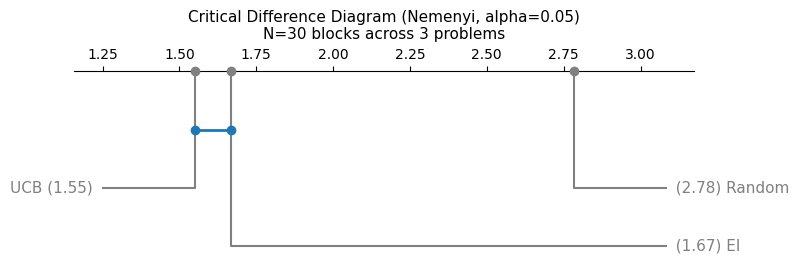

In [5]:
# Critical Difference Diagram (Demšar 2006)
# scikit-posthocs has a built-in function for this

# Compute average ranks per strategy
# Lower rank = better (rank 1 = best in that block)
ranks_per_block = pd.DataFrame(friedman_matrix, columns=STRATEGIES).rank(axis=1)
avg_ranks = ranks_per_block.mean(axis=0)

print("=== Average ranks per strategy ===")
for s in STRATEGIES:
    print(f"  {s:<10} avg rank = {avg_ranks[s]:.4f}")
print()

# Plot CD diagram
fig, ax = plt.subplots(figsize=(8, 2.5))
sp.critical_difference_diagram(
    ranks=avg_ranks,
    sig_matrix=nemenyi_pvalues,
    ax=ax,
    label_fmt_left="{label} ({rank:.2f})  ",
    label_fmt_right="  ({rank:.2f}) {label}",
    text_h_margin=0.3,
    label_props={"fontsize": 11},
    crossbar_props={"color": None, "marker": "o"},
    elbow_props={"color": "gray"},
)
plt.title(
    f"Critical Difference Diagram (Nemenyi, alpha=0.05)\n"
    f"N={len(friedman_matrix)} blocks across {len(PROBLEMS)} problems",
    fontsize=11,
)

# Save the figure
PROJECT_ROOT_FIG = PROJECT_ROOT / "figures"
PROJECT_ROOT_FIG.mkdir(exist_ok=True)
cd_path = PROJECT_ROOT_FIG / "exp_03_cd_diagram.png"
plt.savefig(cd_path, dpi=150, bbox_inches="tight")
print(f"CD diagram saved to {cd_path}")

plt.show()